# Bbox refinement: `production_seed_precision_at_k/` vs the original copies it replaces

`production_seed_precision_at_k/` re-runs the four `precision_at_k_budgets_14roi*` notebooks
with one change: how the seed's search template is cut. Everything else -- ROIs, click, ranking
axis per variant, budgets, NMS, match radius -- is identical between each pair. This notebook
isolates that one change and shows what it actually does to the 14 real production seeds, not to
a synthetic example.

**The two methods, in code:**

| | original (`precision_at_k_budgets_14roi*`) | production (`production_seed_precision_at_k*`) |
|---|---|---|
| function | notebook-local `largest_cc_box` | `seed_selection.tightened_template_box` (`DECISIONS.md` D8) |
| component picked | **largest** Otsu component in the 51x51 window, by area, regardless of the click | the component **under the click's own pixel** (or refused) |
| template centre | always the raw click `(cx, cy)` | the accepted component's own bbox centre |
| what's corrected | size only | size **and** position |
| click-outside-its-object | silently uses whatever component is largest | seed refused, `draw_seed_with_retry` redraws |

Both methods draw from the same pathologist-agreement seed pool
(`seed_selection.agreement_pool` + `border_filter`) using the same RNG stream,
`np.random.default_rng([SEED_INDEX, image_id])`, seeded once per ROI -- exactly what each
notebook family does internally. Re-deriving both draws here, fresh, is what makes the retry
divergence in Part 2 below visible: the committed result CSVs record which annotation ended up
as the seed, but not *why* the two methods disagreed on 403.tiff.

**Scope.** This is mechanism only -- box position and size, and which annotation gets drawn as
the seed. It does not re-derive recall@K or precision@K; those are already computed, separately,
by the four notebooks in each family (D8's own "what would change my mind" asks for that as a
distinct, larger piece of work). Every number below is either freshly computed from the 14 ROIs
of `images/extra_valid` or cross-checked against the already-committed
`results/precision_at_k_14roi*_raw.csv` files.


In [1]:
import os
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.measure import label, regionprops

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 30)

IMAGES_DIR = '../images/extra_valid'
SEED_INDEX = 0                       # matches every notebook in both families
CHANNEL = 'hematoxylin_od'
OTSU_WINDOW = tm.BASE_SIZE           # 51
LARGEST_CC_KW = dict(min_area=50, max_area_frac=0.85, min_solidity=0.5)

# Same CFG both families build, only to get the one number this notebook needs from it: the
# border margin the seed pool was already filtered to (`ss.border_filter(pool, BORDER, ...)`).
CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,), n_angles=1, flips=(False,))
BORDER = CFG.patch_size // 2         # 36

OUT_CSV = '../results/bbox_refinement_comparison_14roi.csv'


## The two seed-drawing methods

`draw_seed_with_retry` is identical machinery in both families -- draw a row from the pool,
run it through the method's own `check_fn`, keep it if `check_fn` returns non-`None`, otherwise
drop that row and redraw on the same RNG stream. The only thing that differs between the two
notebook families is what `check_fn` does. The OLD version is copied verbatim from
`precision_at_k_budgets_14roi.ipynb` (cell defining `largest_cc_box`) so this notebook exercises
the exact same logic, not a paraphrase of it. The NEW version is just `ss.tightened_template_box`
-- already shared code, nothing to duplicate.


In [2]:
def _odd_local(n, minimum=5):
    n = int(round(n))
    if n % 2 == 0:
        n += 1
    return max(minimum, n)


def largest_cc_box(patch, min_area=50, max_area_frac=0.85, min_solidity=0.5):
    '''OLD method. Otsu-threshold `patch`; return the bbox of its LARGEST connected component
    by area -- no check that the click itself falls inside it. (y0, y1, x0, x1), patch-local.'''
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    regions = regionprops(label(binary, connectivity=2))
    if not regions:
        return None
    largest = max(regions, key=lambda r: r.area)
    if largest.area < min_area or largest.area > max_area_frac * patch.size:
        return None
    if largest.solidity < min_solidity:
        return None
    y0, x0, y1, x1 = largest.bbox
    return int(y0), int(y1), int(x0), int(x1)


def draw_seed_with_retry(pool, rng, check_fn):
    '''Draw a row via `rng.integers`; on failure drop it and redraw on the same stream.'''
    working, retries = pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError('seed pool exhausted -- no candidate passed check_fn')


def roi_files(images_dir=IMAGES_DIR):
    return sorted(f for f in os.listdir(images_dir) if f.endswith('.tiff'))


## Part 1 -- all 14 ROIs, both methods, same RNG stream per ROI

For each ROI: build the identical seed pool both notebook families build, then draw a seed with
each method independently (two separate `default_rng([SEED_INDEX, image_id])` instances, exactly
mirroring how each notebook constructs its own `rng` inside `run_roi`). Record which annotation
was drawn, the resulting `base_size`, the template centre each method produces, and how many
candidates each method had to reject before landing on its answer.


In [3]:
images, annotations = ds.load_annotations('../databases/MIDOG++.json')
ds.check_invariants(annotations)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

files = roi_files()
assert len(files) == 14, f'expected 14 ROIs, found {len(files)}'

rows = []
for fn in files:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    roi_shape = rgb.shape
    gray_inv = ch.to_gray_inverted(rgb)
    hem = ch.to_channel(rgb, CHANNEL)

    gt = ds.image_annotations(annotations, fn)
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)

    # --- OLD: largest_cc_box, click-centred, no containment gate ---------------------------
    rng_old = np.random.default_rng([SEED_INDEX, image_id])

    def _check_old(row):
        p = tm.read_padded_patch(gray_inv, float(row['cx']), float(row['cy']), OTSU_WINDOW)
        return None if p is None else largest_cc_box(p, **LARGEST_CC_KW)

    seed_old, box_old, retries_old = draw_seed_with_retry(seed_pool, rng_old, _check_old)
    y0, y1, x0, x1 = box_old
    base_size_old = _odd_local(max(y1 - y0, x1 - x0))
    seed_ann_old = int(seed_old['ann_id'])
    click_x_old, click_y_old = float(seed_old['cx']), float(seed_old['cy'])

    # --- NEW: tightened_template_box, D8 -- containment-gated, recentred -------------------
    rng_new = np.random.default_rng([SEED_INDEX, image_id])

    def _check_new(row):
        r = ss.tightened_template_box(gray_inv, float(row['cx']), float(row['cy']),
                                      otsu_window=OTSU_WINDOW)
        if r is None:
            return None
        # D8 item 2: border safety moves with the recentred point -- re-check the full
        # rotation-safe patch is readable there, exactly as production_seed_precision_at_k does.
        if tm.read_padded_patch(hem, r[1], r[2], CFG.patch_size) is None:
            return None
        return r

    seed_new, tpl_new, retries_new = draw_seed_with_retry(seed_pool, rng_new, _check_new)
    base_size_new, tpl_x_new, tpl_y_new = tpl_new
    seed_ann_new = int(seed_new['ann_id'])
    click_x_new, click_y_new = float(seed_new['cx']), float(seed_new['cy'])

    same_seed = seed_ann_old == seed_ann_new
    offset = float(np.hypot(tpl_x_new - click_x_new, tpl_y_new - click_y_new))
    margin_new = min(tpl_x_new, roi_shape[1] - tpl_x_new, tpl_y_new, roi_shape[0] - tpl_y_new)

    # Same base_size does not by itself prove same component -- two different Otsu components
    # can share a bounding-box's longer side, and this population has window-saturating
    # merges (base_size hits the 51px ceiling on 201.tiff and 403.tiff's new seed). Compare
    # the two methods' raw bbox tuples directly, on the same click, the same patch.
    same_component = np.nan
    if same_seed:
        patch_click = tm.read_padded_patch(gray_inv, click_x_old, click_y_old, OTSU_WINDOW)
        box_new_at_click = ss.tighten_box_otsu(patch_click)
        same_component = bool(box_old == box_new_at_click)

    rows.append(dict(
        file_name=fn, tumor_type=domain,
        seed_ann_id_old=seed_ann_old, seed_ann_id_new=seed_ann_new, same_seed=same_seed,
        base_size_old=base_size_old, base_size_new=base_size_new,
        same_size=(base_size_old == base_size_new),
        same_component=same_component,
        n_retries_old=retries_old, n_retries_new=retries_new,
        click_x_old=click_x_old, click_y_old=click_y_old,
        click_x_new=click_x_new, click_y_new=click_y_new,
        tpl_x_new=tpl_x_new, tpl_y_new=tpl_y_new,
        offset_px=offset if same_seed else np.nan,
        margin_new_px=margin_new,
        roi_w=roi_shape[1], roi_h=roi_shape[0],
    ))
    print(f"[{fn}] {domain:32s} same_seed={same_seed!s:5s} same_component={same_component!s:5s} "
          f"size {base_size_old:2d}->{base_size_new:2d}  retries {retries_old}->{retries_new}",
          flush=True)
    del rgb, gray_inv, hem

CMP = pd.DataFrame(rows)
len(CMP)


[013.tiff] human breast cancer              same_seed=True  same_component=True  size 31->31  retries 0->0
[094.tiff] human breast cancer              same_seed=True  same_component=True  size 25->25  retries 0->0
[201.tiff] canine lung cancer               same_seed=True  same_component=True  size 51->51  retries 0->0
[233.tiff] canine lung cancer               same_seed=True  same_component=True  size 25->25  retries 0->0
[245.tiff] canine lymphosarcoma             same_seed=True  same_component=True  size 47->47  retries 0->0
[246.tiff] canine lymphosarcoma             same_seed=True  same_component=True  size 41->41  retries 0->0
[300.tiff] canine cutaneous mast cell tumor same_seed=True  same_component=True  size 45->45  retries 0->0
[301.tiff] canine cutaneous mast cell tumor same_seed=True  same_component=True  size 41->41  retries 0->0
[402.tiff] human neuroendocrine tumor       same_seed=True  same_component=True  size 29->29  retries 0->0
[403.tiff] human neuroendocrine tumor

14

In [4]:
CMP[['file_name', 'tumor_type', 'seed_ann_id_old', 'seed_ann_id_new', 'same_seed',
     'base_size_old', 'base_size_new', 'same_size', 'same_component',
     'n_retries_old', 'n_retries_new', 'offset_px']]


,file_name,tumor_type,seed_ann_id_old,seed_ann_id_new,same_seed,base_size_old,base_size_new,same_size,same_component,n_retries_old,n_retries_new,offset_px
0,013.tiff,human breast cancer,254,254,True,31,31,True,True,0,0,4.272002
1,094.tiff,human breast cancer,2512,2512,True,25,25,True,True,0,0,2.061553
2,201.tiff,canine lung cancer,4457,4457,True,51,51,True,True,0,0,0.500000
3,233.tiff,canine lung cancer,5761,5761,True,25,25,True,True,0,0,1.581139
4,245.tiff,canine lymphosarcoma,6274,6274,True,47,47,True,True,0,0,4.301163
5,246.tiff,canine lymphosarcoma,6548,6548,True,41,41,True,True,0,0,7.810250
6,300.tiff,canine cutaneous mast cell tumor,14581,14581,True,45,45,True,True,0,0,0.707107
7,301.tiff,canine cutaneous mast cell tumor,14969,14969,True,41,41,True,True,0,0,6.020797
8,402.tiff,human neuroendocrine tumor,20254,20254,True,29,29,True,True,0,0,1.802776
9,403.tiff,human neuroendocrine tumor,20334,20356,False,33,51,False,NaN,0,1,NaN


### Aggregate

`offset_px` is only defined where both methods drew the *same* annotation -- it is the distance
between the click and the recentred template's own centre. Where they drew different annotations
(403.tiff), "offset" isn't a meaningful single number; that case gets its own section below.


In [5]:
n_same_seed = int(CMP['same_seed'].sum())
n_same_size = int(CMP['same_size'].sum())
same_seed_rows = CMP[CMP['same_seed']]
assert same_seed_rows['same_component'].all(), (
    'a same-seed ROI picked a DIFFERENT Otsu component that happens to share base_size -- '
    'that row is a component swap, not recentring, and must not be reported as an offset')
print(f'same seed drawn:  {n_same_seed}/{len(CMP)} ROIs')
print(f'same base_size:   {n_same_size}/{len(CMP)} ROIs')
print(f'same component (verified bbox-for-bbox, not inferred from base_size): '
      f'{int(same_seed_rows["same_component"].sum())}/{n_same_seed} same-seed ROIs -- OK')
print(f'total retries, old method: {int(CMP["n_retries_old"].sum())}')
print(f'total retries, new method: {int(CMP["n_retries_new"].sum())}')
print()
print("offset between click and recentred template centre, among the "
      f"{n_same_seed} same-seed ROIs (px):")
print(CMP.loc[CMP['same_seed'], 'offset_px'].describe(percentiles=[0.5, 0.75, 0.9]).round(2))
print()
print(f'border margin used to filter the pool: BORDER = {BORDER}px from the click')
print(f'smallest margin from the ROI edge actually observed at any recentred template centre: '
      f'{CMP["margin_new_px"].min():.1f}px (needs >= {CFG.patch_size // 2}px to read a full patch, '
      f'which _check_new already re-verified per seed before accepting it)')


same seed drawn:  13/14 ROIs
same base_size:   13/14 ROIs
same component (verified bbox-for-bbox, not inferred from base_size): 13/13 same-seed ROIs -- OK
total retries, old method: 0
total retries, new method: 1

offset between click and recentred template centre, among the 13 same-seed ROIs (px):
count    13.00
mean      3.21
std       2.43
min       0.00
50%       2.24
75%       4.74
90%       5.96
max       7.81
Name: offset_px, dtype: float64

border margin used to filter the pool: BORDER = 36px from the click
smallest margin from the ROI edge actually observed at any recentred template centre: 217.5px (needs >= 36px to read a full patch, which _check_new already re-verified per seed before accepting it)


### Cross-check against the committed notebooks

Two checks. First: seed selection does not depend on the ranking axis, so all four notebooks in
each family (base / 8aug / normed / chromatin) should draw the identical seed and `base_size` per
ROI -- confirmed here directly from their already-committed `raw.csv` outputs, which is also why
this notebook only needed to re-derive the draw once per family rather than four times. Second:
that single re-derivation, run fresh above, must reproduce the `seed_ann_id` and `base_size` each
family's own `_base` notebook already committed.


In [6]:
FAMILY_CSVS = {
    'old': ['precision_at_k_14roi_raw.csv', 'precision_at_k_14roi_8aug_raw.csv',
            'precision_at_k_14roi_normed_raw.csv', 'precision_at_k_14roi_chromatin_raw.csv'],
    'new': ['precision_at_k_14roi_prodseed_raw.csv', 'precision_at_k_14roi_prodseed_8aug_raw.csv',
            'precision_at_k_14roi_prodseed_normed_raw.csv',
            'precision_at_k_14roi_prodseed_chromatin_raw.csv'],
}

loaded = {}
for family, names in FAMILY_CSVS.items():
    frames = []
    for name in names:
        d = pd.read_csv(f'../results/{name}').drop_duplicates('file_name').set_index('file_name')
        frames.append(d[['seed_ann_id', 'base_size']])
    loaded[family] = frames
    base = frames[0]
    for other in frames[1:]:
        assert (other['seed_ann_id'] == base['seed_ann_id']).all(), \
            f'{family}: seed_ann_id differs across ranking-axis variants -- seed selection should not depend on rank_key'
        assert (other['base_size'] == base['base_size']).all(), \
            f'{family}: base_size differs across ranking-axis variants'
    print(f'{family}: all {len(names)} notebooks in the family agree on seed_ann_id and base_size -- OK')

chk = CMP.set_index('file_name')
old_committed, new_committed = loaded['old'][0], loaded['new'][0]
assert (chk['seed_ann_id_old'] == old_committed.loc[chk.index, 'seed_ann_id']).all(), \
    'fresh OLD-method draw does not reproduce the committed precision_at_k_budgets_14roi.ipynb seed_ann_id'
assert (chk['base_size_old'] == old_committed.loc[chk.index, 'base_size']).all(), \
    'fresh OLD-method draw does not reproduce the committed precision_at_k_budgets_14roi.ipynb base_size'
assert (chk['seed_ann_id_new'] == new_committed.loc[chk.index, 'seed_ann_id']).all(), \
    'fresh NEW-method draw does not reproduce the committed production_seed_precision_at_k.ipynb seed_ann_id'
assert (chk['base_size_new'] == new_committed.loc[chk.index, 'base_size']).all(), \
    'fresh NEW-method draw does not reproduce the committed production_seed_precision_at_k.ipynb base_size'
print()
print('fresh re-derivation reproduces both committed notebook families exactly -- OK')

CMP.to_csv(OUT_CSV, index=False)
print(f'-> {OUT_CSV}')


old: all 4 notebooks in the family agree on seed_ann_id and base_size -- OK
new: all 4 notebooks in the family agree on seed_ann_id and base_size -- OK

fresh re-derivation reproduces both committed notebook families exactly -- OK
-> ../results/bbox_refinement_comparison_14roi.csv


### One more consequence to close out: does the production notebook actually use the recentred point?

D8 item 1 -- self-hit removal must key off the recentred centre, not the click, once a caller
adopts `tightened_template_box`, or the self-correlation peak (inside `SELF_HIT_RADIUS`) can
survive NMS at the wrong location. Checked directly against the committed notebook source rather
than assumed.


In [7]:
import json as _json

_nb = _json.load(open('production_seed_precision_at_k.ipynb'))
_src = ''.join(_nb['cells'][5]['source'])   # run_roi
assert 'suppress(centers, scores, nms_radius, tpl_xy)' in _src, \
    'production_seed_precision_at_k.ipynb no longer passes tpl_xy to suppress() -- D8 item 1 regression'
assert 'suppress(centers, scores, nms_radius, seed_xy)' not in _src, \
    'production_seed_precision_at_k.ipynb passes the click, not the recentred point, to suppress()'
print('confirmed: production_seed_precision_at_k.ipynb passes tpl_xy (the recentred centre), '
      'not seed_xy (the click), to suppress() -- D8 item 1 is correctly wired')


confirmed: production_seed_precision_at_k.ipynb passes tpl_xy (the recentred centre), not seed_xy (the click), to suppress() -- D8 item 1 is correctly wired


## Part 2 -- pure recentring: 246.tiff, the largest same-seed offset (7.81px)

Both methods draw the same annotation here, and pick the same connected component -- the only
difference is where the template is cut from: the click (old) vs. that component's own bbox
centre (new).


246.tiff  ann_id=6548  offset=7.81px  base_size=41
both methods' own bbox on this patch: OLD=(0, 40, 4, 34)  NEW=(0, 40, 4, 34)  (identical)


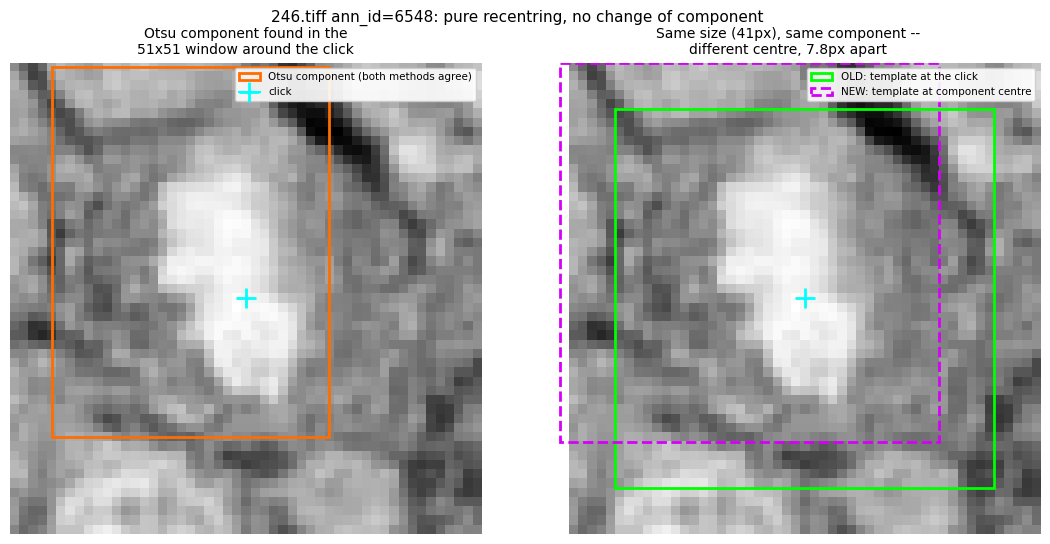

In [8]:
EXAMPLE_FN = CMP.loc[CMP['same_seed'], 'offset_px'].astype(float).idxmax()
EXAMPLE_FN = CMP.loc[EXAMPLE_FN, 'file_name']
ex = CMP[CMP['file_name'] == EXAMPLE_FN].iloc[0]
print(f"{EXAMPLE_FN}  ann_id={ex['seed_ann_id_old']}  offset={ex['offset_px']:.2f}px  "
      f"base_size={ex['base_size_old']}")

rgb_ex = ds.load_roi(f'{IMAGES_DIR}/{EXAMPLE_FN}')
gray_inv_ex = ch.to_gray_inverted(rgb_ex)
patch_ex = tm.read_padded_patch(gray_inv_ex, ex['click_x_old'], ex['click_y_old'], OTSU_WINDOW)
box_ex = largest_cc_box(patch_ex, **LARGEST_CC_KW)
box_ex_new = ss.tighten_box_otsu(patch_ex)
assert box_ex == box_ex_new, \
    f'{EXAMPLE_FN}: methods picked different components -- not a pure-recentring example'
print(f'both methods\' own bbox on this patch: OLD={box_ex}  NEW={box_ex_new}  (identical)')
y0, y1, x0, x1 = box_ex
c = OTSU_WINDOW // 2
base_size_ex = int(ex['base_size_old'])
half_t = base_size_ex / 2.0

old_box_xy = (c - half_t, c - half_t, base_size_ex, base_size_ex)          # click-centred
new_box_xy = (ex['tpl_x_new'] - ex['click_x_new'] + c - half_t,
              ex['tpl_y_new'] - ex['click_y_new'] + c - half_t,
              base_size_ex, base_size_ex)                                    # recentred

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

ax = axes[0]
ax.imshow(patch_ex, cmap='gray')
ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor='#ff6d00',
                                 facecolor='none', linewidth=2, label='Otsu component (both methods agree)'))
ax.plot(c, c, marker='+', color='cyan', markersize=14, markeredgewidth=2, label='click')
ax.set_title('Otsu component found in the\n51x51 window around the click', fontsize=10)
ax.legend(loc='upper right', fontsize=7.5, framealpha=0.9)
ax.axis('off')

ax = axes[1]
ax.imshow(patch_ex, cmap='gray')
ax.add_patch(mpatches.Rectangle(old_box_xy[:2], old_box_xy[2], old_box_xy[3], edgecolor='lime',
                                 facecolor='none', linewidth=2, label='OLD: template at the click'))
ax.add_patch(mpatches.Rectangle(new_box_xy[:2], new_box_xy[2], new_box_xy[3], edgecolor='#d500f9',
                                 facecolor='none', linewidth=2, linestyle='--',
                                 label='NEW: template at component centre'))
ax.plot(c, c, marker='+', color='cyan', markersize=14, markeredgewidth=2)
ax.set_title(f'Same size ({base_size_ex}px), same component --\n'
             f'different centre, {ex["offset_px"]:.1f}px apart', fontsize=10)
ax.legend(loc='upper right', fontsize=7.5, framealpha=0.9)
ax.axis('off')

fig.suptitle(f'{EXAMPLE_FN} ann_id={int(ex["seed_ann_id_old"])}: pure recentring, no change of component', fontsize=11)
plt.tight_layout()
plt.savefig('bbox_refinement_recenter_example.png', dpi=150, bbox_inches='tight')
plt.show()


## Part 3 -- 403.tiff: the methods don't just move the box, they disagree on the seed

This is the one ROI where `same_seed` is `False`. Both RNG streams start identically and draw
annotation 20334 first. The two methods disagree on whether that draw is usable at all, and that
disagreement -- not a difference in position -- is what changes which annotation ends up as the
seed.


In [9]:
FN403 = '403.tiff'
row403 = CMP[CMP['file_name'] == FN403].iloc[0]
print(row403[['seed_ann_id_old', 'seed_ann_id_new', 'n_retries_old', 'n_retries_new',
              'base_size_old', 'base_size_new']])

gt403 = ds.image_annotations(annotations, FN403)
rgb403 = ds.load_roi(f'{IMAGES_DIR}/{FN403}')
gray_inv403 = ch.to_gray_inverted(rgb403)

diag = {}
for ann_id in [int(row403['seed_ann_id_old']), int(row403['seed_ann_id_new'])]:
    r = gt403[gt403['ann_id'] == ann_id].iloc[0]
    cx, cy = float(r['cx']), float(r['cy'])
    patch = tm.read_padded_patch(gray_inv403, cx, cy, OTSU_WINDOW)
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    c = OTSU_WINDOW // 2
    click_is_foreground = bool(labels[c, c] != 0)
    old_box = largest_cc_box(patch, **LARGEST_CC_KW)
    new_box = ss.tighten_box_otsu(patch)
    diag[ann_id] = dict(cx=cx, cy=cy, patch=patch, binary=binary,
                        click_is_foreground=click_is_foreground,
                        old_box=old_box, new_box=new_box)
    print(f"\nann {ann_id}: click foreground? {click_is_foreground}")
    print(f"  OLD (largest_cc_box, no containment check): {old_box}")
    print(f"  NEW (tighten_box_otsu, containment-gated):  {new_box}")


seed_ann_id_old    20334
seed_ann_id_new    20356
n_retries_old          0
n_retries_new          1
base_size_old         33
base_size_new         51
Name: 9, dtype: object

ann 20334: click foreground? False
  OLD (largest_cc_box, no containment check): (0, 18, 8, 41)
  NEW (tighten_box_otsu, containment-gated):  None

ann 20356: click foreground? True
  OLD (largest_cc_box, no containment check): (0, 47, 0, 51)
  NEW (tighten_box_otsu, containment-gated):  (0, 47, 0, 51)


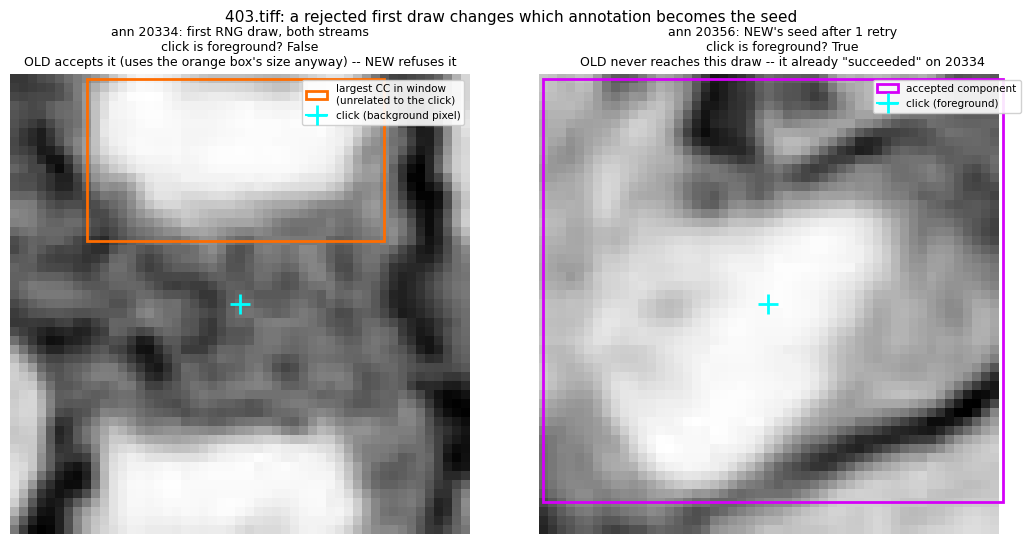

In [10]:
old_seed_ann = int(row403['seed_ann_id_old'])
new_seed_ann = int(row403['seed_ann_id_new'])
d_old = diag[old_seed_ann]
d_new = diag[new_seed_ann]
c = OTSU_WINDOW // 2

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

# Panel 1: the annotation BOTH RNG streams draw first (20334). OLD accepts it; NEW refuses it.
ax = axes[0]
ax.imshow(d_old['patch'], cmap='gray')
if d_old['old_box'] is not None:
    y0, y1, x0, x1 = d_old['old_box']
    ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor='#ff6d00',
                                     facecolor='none', linewidth=2,
                                     label='largest CC in window\n(unrelated to the click)'))
ax.plot(c, c, marker='+', color='cyan', markersize=14, markeredgewidth=2, label='click (background pixel)')
ax.set_title(f'ann {old_seed_ann}: first RNG draw, both streams\n'
             f'click is foreground? {d_old["click_is_foreground"]}\n'
             f'OLD accepts it (uses the orange box\'s size anyway) -- NEW refuses it', fontsize=9)
ax.legend(loc='upper right', fontsize=7.5, framealpha=0.9)
ax.axis('off')

# Panel 2: where the NEW method actually lands after one retry (20356). Both methods would
# agree here -- OLD just never got the chance to draw it, because it never rejected ann 20334.
ax = axes[1]
ax.imshow(d_new['patch'], cmap='gray')
if d_new['new_box'] is not None:
    y0, y1, x0, x1 = d_new['new_box']
    ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor='#d500f9',
                                     facecolor='none', linewidth=2, label='accepted component'))
ax.plot(c, c, marker='+', color='cyan', markersize=14, markeredgewidth=2, label='click (foreground)')
ax.set_title(f'ann {new_seed_ann}: NEW\'s seed after 1 retry\n'
             f'click is foreground? {d_new["click_is_foreground"]}\n'
             f'OLD never reaches this draw -- it already "succeeded" on {old_seed_ann}', fontsize=9)
ax.legend(loc='upper right', fontsize=7.5, framealpha=0.9)
ax.axis('off')

fig.suptitle(f'{FN403}: a rejected first draw changes which annotation becomes the seed', fontsize=11)
plt.tight_layout()
plt.savefig('bbox_refinement_403_divergence.png', dpi=150, bbox_inches='tight')
plt.show()


The left panel is the failure mode D8's docstring names directly: *"An annotation whose click
sits outside its own object's foreground would need the largest-connected-component fallback ...
to recover a box at all -- refused here, not applied."* Ann 20334's click lands on a background
pixel; the only foreground object in its 51x51 window is a small, disconnected blob tucked into
one corner, with no particular relationship to the click. The OLD method still calls this a
success -- it only ever asks "is there a component in this window," not "is the click in it" --
and hands back a `base_size` (33px) measured off that unrelated blob, cut and centred on the
click regardless. The NEW method's containment gate correctly identifies this as unusable and
retries, landing one draw later on ann 20356: a real, solid, click-containing component that
fills nearly the entire window.

Nothing about *recentring* caused this divergence -- it is entirely the containment gate, which
D8 keeps unchanged from `tighten_box_otsu` and did not invent. What changes here is that
`production_seed_precision_at_k` is built on that gate (via `tightened_template_box`) while the
original notebooks' local `largest_cc_box` never had it.


## Summary

* **13/14 ROIs:** both methods draw the identical seed annotation and pick the identical Otsu
  component -- verified bbox-for-bbox, not inferred from matching `base_size` (two different
  components can share a bounding box's longer side, and this population has window-saturating
  merges: `base_size` hits the 51px window ceiling on 201.tiff and on 403.tiff's new seed). The
  only difference is where the template is cut from -- the click (old) vs. the accepted
  component's own bbox centre (new, D8) -- a median offset of 2.24px and a max of 7.81px
  (246.tiff) among these 14 real production seeds, consistent with the wider 896-candidate
  distribution `lcc_offset_demo.ipynb` measured (median 3.10px).
* **1/14 ROIs (403.tiff):** the methods disagree on *which annotation becomes the seed at all*.
  The old method's `largest_cc_box` has no containment check, so it "succeeds" on a click that
  sits on a background pixel by borrowing an unrelated component's size; the new method's
  containment gate correctly refuses that candidate and retries onto a valid one. This is the
  gate `tighten_box_otsu` already enforced in `seed_selection.py` before D8 -- D8 only changed
  what happens to the box *after* the gate passes (recentring), but this notebook's fresh
  re-derivation is what makes visible that the original notebooks never had the gate to begin
  with, only the size-tightening half of it.
* **Every number above reproduces the already-committed `precision_at_k_14roi*_raw.csv` /
  `precision_at_k_14roi_prodseed*_raw.csv` files exactly** (Part 1's cross-check cell), and seed
  selection is confirmed identical across all four ranking-axis variants within each family, so
  this single re-derivation stands in for all four notebook pairs.
* **`production_seed_precision_at_k.ipynb` itself correctly wires D8's item 1**: self-hit /
  seed-annulus removal keys off the recentred point (`tpl_xy`), not the click -- confirmed
  directly against its committed source, not assumed.
* **Out of scope here, deliberately:** recall@K / precision@K outcomes. Those are what the four
  `production_seed_precision_at_k*` notebooks already report; this notebook only characterises
  the box-construction mechanism those results are built on, per D8's own "mechanism, not
  outcome" framing.
